# Visión artificial: de píxeles a características aprendidas

**Ver → contar → detectar → aprender.** Este notebook conecta los histogramas con dos ideas de las redes convolucionales: extraer patrones locales y aprender filtros usando ejemplos etiquetados.

Las animaciones tienen controles para **reproducir, pausar y avanzar un cuadro a la vez**. Sus cuadros están guardados en el notebook. Si el visor bloquea las animaciones, abre el archivo en Jupyter y ejecuta sus celdas. Las celdas de dibujo pueden mantenerse plegadas: los cálculos esenciales aparecen por separado.

Para ejecutar se usan **NumPy, Matplotlib e IPython**, sin descargar conjuntos de datos. Si faltan, ejecuta `%pip install numpy matplotlib ipython` en una celda y reinicia el kernel.

## ¿Qué problema queremos resolver?

En reconocimiento de dígitos, la entrada es una imagen y la respuesta deseada es una clase, como **7**. Durante el entrenamiento se proporcionan ejemplos con su respuesta correcta: eso es **aprendizaje supervisado**.

| Concepto | Reconocer dígitos | Nuestro experimento pequeño |
|---|---|---|
| Entrada | Píxeles de una imagen | Píxeles de una región de 3×3 |
| Etiqueta | El dígito correcto: 0–9 | Más claro a la derecha (+1) o izquierda (−1) |
| Parámetros aprendidos | Pesos de filtros y otras capas | Los nueve pesos de un filtro |
| Características | Respuestas a patrones útiles para distinguir dígitos | Respuesta al contraste izquierda–derecha |

**Los píxeles son los datos de entrada; las características internas son patrones extraídos de ellos.** Un filtro contiene pesos y produce una respuesta. Al aplicarlo en distintas posiciones obtenemos un mapa de características.

Una CNN puede aprender detectores de contrastes, trazos u otras combinaciones útiles. No recibe una lista obligatoria de “borde, esquina, círculo”: los patrones dependen de los datos, la arquitectura y la tarea. Las etiquetas supervisan el resultado final; no indican directamente qué debe detectar cada filtro.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML, display

plt.rcParams.update({"font.size": 11, "figure.dpi": 90, "animation.embed_limit": 60})
AZUL, NARANJA, MORADO = "#167d9a", "#d97706", "#a21caf"


def dibujar_matriz(ax, datos, titulo, pesos=False, limite=3):
    ax.clear()
    datos = np.asarray(datos, dtype=float)
    color = plt.get_cmap("RdBu").copy() if pesos else plt.get_cmap("gray").copy()
    color.set_bad("#e2e8f0")
    ax.imshow(np.ma.masked_invalid(datos), cmap=color,
              vmin=-limite if pesos else 0, vmax=limite if pesos else 1)
    for (i, j), valor in np.ndenumerate(datos):
        etiqueta = "·" if np.isnan(valor) else ("0" if abs(valor) < 1e-10 else f"{valor:.2g}")
        tinta = "white" if not np.isnan(valor) and ((not pesos and valor < 0.5) or (pesos and abs(valor) > limite * 0.6)) else "#172033"
        ax.text(j, i, etiqueta, ha="center", va="center", color=tinta, fontsize=13)
    ax.set_xticks(np.arange(datos.shape[1]))
    ax.set_yticks(np.arange(datos.shape[0]))
    ax.set_xticks(np.arange(-0.5, datos.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, datos.shape[0]), minor=True)
    ax.grid(which="minor", color="#94a3b8", linewidth=0.7)
    ax.tick_params(which="both", length=0)
    ax.set_title(titulo, pad=12)


def marco(ax, fila, columna, tamaño=1):
    ax.add_patch(Rectangle((columna - 0.48, fila - 0.48), tamaño - 0.04, tamaño - 0.04,
                           fill=False, edgecolor=MORADO, linewidth=3))


def animar(fig, actualizar, cuadros, intervalo=900):
    animacion = FuncAnimation(fig, actualizar, frames=cuadros, interval=intervalo,
                              repeat=False, blit=False)
    contenido = animacion.to_jshtml(default_mode="once")
    plt.close(fig)
    display(HTML(contenido))


## 1. Una imagen son números organizados

El **0 representa negro** y el **1 representa blanco**. Esta imagen tiene 25 píxeles. Al invertir las filas cambia la figura, aunque conserva los mismos valores.

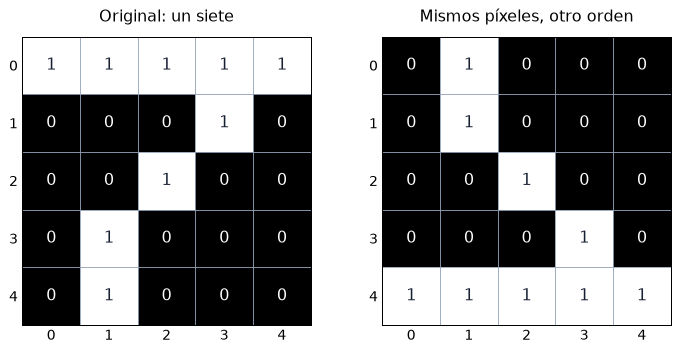

In [2]:
imagen = np.array([
    [1, 1, 1, 1, 1],
    [0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
])
invertida = imagen[::-1]

fig, ejes = plt.subplots(1, 2, figsize=(8, 3.8), layout="constrained")
dibujar_matriz(ejes[0], imagen, "Original: un siete")
dibujar_matriz(ejes[1], invertida, "Mismos píxeles, otro orden")
plt.show()

## 2. Histograma: ¿cuántos píxeles hay de cada intensidad?

La animación recorre los píxeles. Cada visita suma uno a una de las dos barras. El marco morado señala el píxel contado en ese cuadro.

In [3]:
def histograma(imagen):
    return [int(np.sum(imagen == 0)), int(np.sum(imagen == 1))]

print("Original [negros, blancos]: ", histograma(imagen))
print("Invertida [negros, blancos]:", histograma(invertida))

Original [negros, blancos]:  [16, 9]
Invertida [negros, blancos]: [16, 9]


In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(9, 4.3))
fig.subplots_adjust(bottom=0.2, top=0.82, wspace=0.4)
estado = fig.text(0.5, 0.05, "", ha="center", fontsize=12)


def contar_cuadro(n):
    dibujar_matriz(ejes[0], imagen, "Píxel que se cuenta")
    vistos = imagen.ravel()[:n]
    conteos = [int(np.sum(vistos == 0)), int(np.sum(vistos == 1))]
    if n:
        fila, columna = divmod(n - 1, 5)
        marco(ejes[0], fila, columna)
    ax = ejes[1]
    ax.clear()
    ax.bar(["Negro (0)", "Blanco (1)"], conteos, color=["#334155", AZUL])
    ax.set_ylim(0, 18)
    ax.set_yticks([0, 4, 8, 12, 16])
    ax.set_ylabel("Cantidad de píxeles")
    ax.set_title("Histograma acumulado")
    for i, cantidad in enumerate(conteos):
        ax.text(i, cantidad + 0.5, str(cantidad), ha="center", fontsize=14)
    estado.set_text(f"{n} de 25 píxeles contados: {conteos[0]} negros + {conteos[1]} blancos")


animar(fig, contar_cuadro, cuadros=26, intervalo=450)

Animación con controles de reproducción

**Resultado: 16 negros y 9 blancos en ambas imágenes.** El histograma descarta las posiciones, así que no puede distinguir estas dos figuras. Es como contar piezas LEGO por color sin observar cómo están unidas.

Para distinguir formas, necesitamos operaciones que tengan en cuenta **dónde están los píxeles respecto a sus vecinos**.

## 3. Un filtro: multiplicar y sumar

Este kernel de 3×3 compara columnas: pesos **−1 a la izquierda**, **0 en el centro** y **+1 a la derecha**. Cada píxel se multiplica por su peso y se suman los nueve productos.

En este borde de ejemplo hay tres blancos a la derecha. Cada uno aporta `1 × 1 = 1`, por lo que la respuesta total es **3**. No es una probabilidad ni el dígito reconocido: es una medida de contraste.

In [5]:
region = np.array([[0, 0, 1], [0, 0, 1], [0, 0, 1]])
kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

productos = region * kernel
respuesta = productos.sum()
print("Respuesta del filtro:", respuesta)

Respuesta del filtro: 3


In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(10, 4))
fig.subplots_adjust(bottom=0.24, top=0.80, wspace=0.35)
estado = fig.text(0.5, 0.07, "", ha="center", fontsize=13)


def multiplicar_cuadro(n):
    visibles = np.full((3, 3), np.nan)
    visibles.ravel()[:n] = productos.ravel()[:n]
    dibujar_matriz(ejes[0], region, "Píxel")
    dibujar_matriz(ejes[1], kernel, "Peso del filtro", pesos=True, limite=1)
    dibujar_matriz(ejes[2], visibles, "Producto: píxel × peso", pesos=True, limite=1)
    suma = int(productos.ravel()[:n].sum())
    if n:
        i, j = divmod(n - 1, 3)
        for ax in ejes:
            marco(ax, i, j)
        estado.set_text(f"Paso {n}/9: {region[i,j]} × ({kernel[i,j]}) = {productos[i,j]}     |     Suma acumulada = {suma}")
    else:
        estado.set_text("Nueve multiplicaciones y una suma. Los puntos aún no se han calculado.")


animar(fig, multiplicar_cuadro, cuadros=10)

Animación con controles de reproducción

### ¿Por qué funciona como detector de contraste?

Sumar la derecha y restar la izquierda produce respuestas distintas según la orientación. En una región uniforme se cancelan. **Una respuesta cero no descarta todos los patrones posibles:** solo indica que este filtro obtuvo sumas iguales.

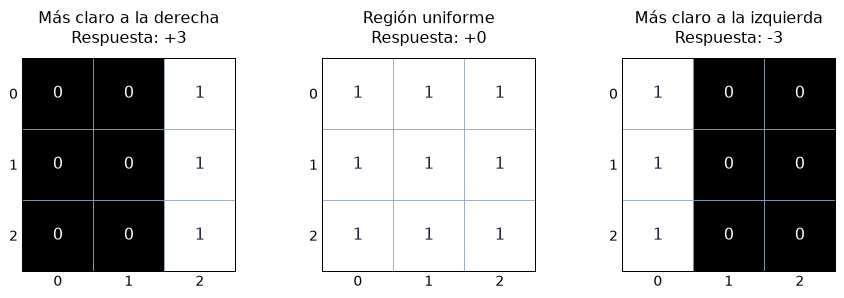

In [7]:
regiones = [region, np.ones((3, 3), dtype=int), region[:, ::-1]]
nombres = ["Más claro a la derecha", "Región uniforme", "Más claro a la izquierda"]
fig, ejes = plt.subplots(1, 3, figsize=(10, 3.2), layout="constrained")
for ax, bloque, nombre in zip(ejes, regiones, nombres):
    valor = int((bloque * kernel).sum())
    dibujar_matriz(ax, bloque, f"{nombre}\nRespuesta: {valor:+d}")
plt.show()

## 4. Convolución: repetir el filtro en distintas posiciones

El mismo filtro recorre la imagen completa. Cada respuesta se guarda en una casilla del **mapa de características**.

La ventana cabe en `5 − 3 + 1 = 3` posiciones por dimensión. Por eso una imagen de 5×5 produce un mapa de 3×3, avanzando un píxel y sin añadir relleno.

In [8]:
def convolucion(imagen, kernel):
    alto = imagen.shape[0] - kernel.shape[0] + 1
    ancho = imagen.shape[1] - kernel.shape[1] + 1
    mapa = np.zeros((alto, ancho))
    for fila in range(alto):
        for columna in range(ancho):
            ventana = imagen[fila:fila + 3, columna:columna + 3]
            mapa[fila, columna] = np.sum(ventana * kernel)
    return mapa

mapa = convolucion(imagen, kernel)
print(mapa)

[[ 1.  1. -1.]
 [ 1.  0. -1.]
 [ 1. -2. -1.]]


In [9]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 4.5))
fig.subplots_adjust(bottom=0.24, top=0.80, wspace=0.4)
estado = fig.text(0.5, 0.07, "", ha="center", fontsize=12)


def deslizar_cuadro(n):
    fila, columna = divmod(n, 3)
    ventana = imagen[fila:fila + 3, columna:columna + 3]
    productos_locales = ventana * kernel
    parcial = np.full((3, 3), np.nan)
    parcial.ravel()[:n + 1] = mapa.ravel()[:n + 1]
    dibujar_matriz(ejes[0], imagen, "1. Seleccionar región")
    marco(ejes[0], fila, columna, tamaño=3)
    dibujar_matriz(ejes[1], productos_locales, "2. Multiplicar por el kernel", pesos=True)
    dibujar_matriz(ejes[2], parcial, "3. Guardar la suma", pesos=True)
    marco(ejes[2], fila, columna)
    estado.set_text(f"Ventana {n+1}/9 · posición ({fila}, {columna}) · suma = {mapa[fila,columna]:g}\nAzul: positivo · Naranja: negativo · Punto: todavía sin calcular")


animar(fig, deslizar_cuadro, cuadros=9, intervalo=1400)

Animación con controles de reproducción

**La característica es la respuesta al contraste en cada ubicación.** Todavía no hemos clasificado el siete. Para reconocer un dígito completo, una red combina respuestas de muchos filtros y capas.

Hasta aquí elegimos los pesos a mano. Técnicamente calculamos correlación cruzada, porque no invertimos el kernel; en CNN es habitual llamarla convolución.

## 5. Aprendizaje supervisado: aprender el filtro

Ahora sí vamos a aprender sus nueve pesos. La tarea pequeña es distinguir **qué lado de una región está más claro**.

Creamos seis ejemplos etiquetados: tres con mayor intensidad a la derecha (**+1**) y tres a la izquierda (**−1**), con distintos tonos de gris. Las parejas contienen las mismas intensidades, pero en posiciones opuestas.

Las etiquetas representan la respuesta correcta. **No entregamos al entrenamiento los pesos del filtro anterior**: el nuevo filtro comienza con nueve ceros.

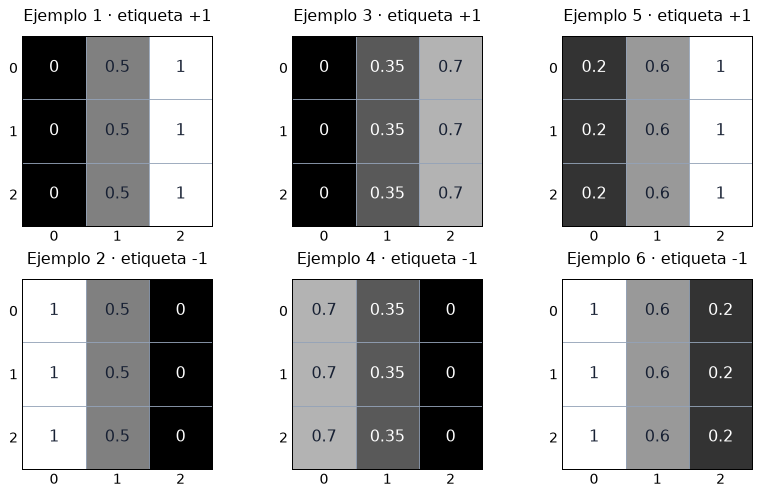

In [10]:
ejemplos, etiquetas = [], []
for oscuro, claro in [(0.0, 1.0), (0.0, 0.7), (0.2, 1.0)]:
    centro = (oscuro + claro) / 2
    derecha = np.tile([oscuro, centro, claro], (3, 1))
    ejemplos.extend([derecha, derecha[:, ::-1]])
    etiquetas.extend([1.0, -1.0])

X = np.array(ejemplos)
y = np.array(etiquetas)

fig, ejes = plt.subplots(2, 3, figsize=(9, 5.4), layout="constrained")
for columna in range(3):
    for fila in range(2):
        i = 2 * columna + fila
        dibujar_matriz(ejes[fila, columna], X[i], f"Ejemplo {i+1} · etiqueta {y[i]:+.0f}")
plt.show()

### Predicción → error → gradiente → actualización

La predicción es la suma `imagen × filtro`. Una respuesta positiva se interpreta como **derecha más clara**; una negativa, como **izquierda más clara**. Cero es un empate.

1. Calculamos las respuestas del filtro para los seis ejemplos.
2. Medimos el promedio de `(predicción − etiqueta)²`.
3. Calculamos cómo cambia ese error al modificar cada peso: el **gradiente**.
4. Restamos un pequeño múltiplo del gradiente a los pesos.

Para un peso, el gradiente es el promedio de `2 × error_de_predicción × píxel`. El mismo peso se actualiza usando todos los ejemplos. Así un patrón consistente en los datos orienta el aprendizaje.

In [11]:
filtro = np.zeros((3, 3))
paso = 0.08
historial = []

for iteracion in range(31):
    predicciones = np.sum(X * filtro, axis=(1, 2))
    errores = predicciones - y
    perdida = np.mean(errores ** 2)
    historial.append((filtro.copy(), predicciones.copy(), float(perdida)))
    gradiente = np.mean(2 * errores[:, None, None] * X, axis=0)
    if iteracion < 30:
        filtro -= paso * gradiente

print("Filtro aprendido:\n", np.round(filtro, 3))
print("Etiquetas:   ", y.astype(int))
print("Predicciones:", np.round(historial[-1][1], 3))
print("Clases:      ", np.sign(historial[-1][1]).astype(int))

Filtro aprendido:
 [[-0.39  0.    0.39]
 [-0.39  0.    0.39]
 [-0.39  0.    0.39]]
Etiquetas:    [ 1 -1  1 -1  1 -1]
Predicciones: [ 1.169 -1.169  0.819 -0.819  0.936 -0.936]
Clases:       [ 1 -1  1 -1  1 -1]


In [12]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 4.6))
fig.subplots_adjust(bottom=0.25, top=0.78, wspace=0.55)
estado = fig.text(0.5, 0.06, "", ha="center", fontsize=12)
perdidas = [registro[2] for registro in historial]


def aprender_cuadro(n):
    pesos, respuestas, perdida = historial[n]
    dibujar_matriz(ejes[0], pesos, "Pesos que se aprenden", pesos=True, limite=0.5)
    ax = ejes[1]
    ax.clear()
    posiciones = np.arange(1, 7)
    ax.scatter(posiciones, y, marker="x", s=90, color="#111827", label="Etiqueta", zorder=3)
    ax.scatter(posiciones, respuestas, s=65, color=AZUL, label="Predicción", zorder=4)
    ax.axhline(0, color="#94a3b8", linewidth=1)
    ax.set(xlim=(0.5, 6.5), ylim=(-1.6, 1.6), xticks=posiciones, xlabel="Ejemplo", title="Respuestas frente a etiquetas")
    ax.legend(loc="upper center", fontsize=8, ncol=2, bbox_to_anchor=(0.5, 1.02))
    ax = ejes[2]
    ax.clear()
    ax.plot(range(n+1), perdidas[:n+1], color=AZUL)
    ax.scatter([n], [perdida], color=NARANJA, zorder=3)
    ax.set(xlim=(0, 30), ylim=(0, 1.05), xlabel="Actualización", ylabel="Error cuadrático medio", title="Error de entrenamiento")
    correctas = int(np.sum(np.sign(respuestas) == y))
    estado.set_text(f"Actualización {n}/30 · error = {perdida:.4f} · clases correctas = {correctas}/6\nLos pesos izquierdos se vuelven negativos; los derechos, positivos.")


animar(fig, aprender_cuadro, cuadros=len(historial), intervalo=550)

Animación con controles de reproducción

### ¿Qué aprendió y por qué?

El filtro aprendió a **restar intensidad de la izquierda y sumar intensidad de la derecha**, sin recibir esos pesos como solución. La organización de los ejemplos y sus etiquetas produjo esa dirección de cambio.

Por ejemplo, al inicio todos los pesos son cero. Para una imagen con etiqueta +1, la predicción es 0 y la diferencia es −1. En un píxel claro de la derecha, el gradiente es negativo; al restarlo, el peso aumenta. Las imágenes con etiqueta −1 impulsan el cambio contrario en la izquierda.

El centro permanece cerca de cero porque aporta valores iguales en ejemplos de etiquetas opuestas: sus contribuciones se cancelan en este conjunto simétrico. Los ejemplos tampoco varían entre filas, por eso se aprenden pesos iguales en cada fila.

**Aprender características no significa inventar la tarea:** nosotros elegimos los ejemplos, las etiquetas, la estructura y el error. El algoritmo ajusta los pesos. Aquí aprendió un contraste local, no un detector de sietes.

## 6. ¿Qué indica el gradiente? Una vista de la pendiente

Podemos explorar una familia sencilla de filtros con un solo parámetro `a`:

```
−a   0   +a
−a   0   +a
−a   0   +a
```

El valor `a` controla la fuerza del contraste. La curva representa el error de estos filtros sobre los mismos seis ejemplos. La pendiente indica hacia dónde crece el error; avanzar en la dirección contraria permite reducirlo con un paso adecuado.

Esta es una vista separada de un parámetro, no una proyección exacta de todos los pasos del entrenamiento anterior.

In [13]:
base = np.array([[-1., 0., 1.]] * 3)
contrastes = np.sum(X * base, axis=(1, 2))
a, paso_a = 0.0, 0.04
trayectoria = []

for iteracion in range(11):
    diferencias = a * contrastes - y
    error = float(np.mean(diferencias ** 2))
    pendiente = float(np.mean(2 * diferencias * contrastes))
    trayectoria.append((a, error, pendiente))
    a -= paso_a * pendiente

valores_a = np.linspace(-0.08, 0.8, 250)
curva_error = np.mean((valores_a[:, None] * contrastes - y) ** 2, axis=1)

In [14]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.subplots_adjust(bottom=0.24, top=0.82, wspace=0.4)
estado = fig.text(0.5, 0.06, "", ha="center", fontsize=12)


def pendiente_cuadro(n):
    a, error, pendiente = trayectoria[n]
    ax = ejes[0]
    ax.clear()
    ax.plot(valores_a, curva_error, color=AZUL, label="Error")
    tangente_x = np.array([a - 0.06, a + 0.06])
    ax.plot(tangente_x, error + pendiente * (tangente_x - a), color=NARANJA, linewidth=3, label="Pendiente local")
    ax.scatter([a], [error], color=MORADO, s=65, zorder=5)
    if n + 1 < len(trayectoria):
        siguiente_a, siguiente_error, _ = trayectoria[n + 1]
        ax.annotate("", xy=(siguiente_a, siguiente_error), xytext=(a, error), arrowprops={"arrowstyle":"->", "color":MORADO, "lw":2})
    ax.set(xlim=(-0.08, 0.8), ylim=(-0.08, float(curva_error.max()) + 0.1), xlabel="Parámetro a", ylabel="Error cuadrático medio", title="Descender por la curva de error")
    ax.legend(fontsize=9)
    dibujar_matriz(ejes[1], a * base, "Filtro correspondiente", pesos=True, limite=0.5)
    estado.set_text(f"Paso {n}: a = {a:.4f} · pendiente = {pendiente:.4f} · error = {error:.4f}\na siguiente = {a:.4f} − {paso_a} × ({pendiente:.4f})")


animar(fig, pendiente_cuadro, cuadros=len(trayectoria), intervalo=1100)

Animación con controles de reproducción

Cuando la pendiente es negativa, restarla aumenta `a`; cerca del mínimo la pendiente se acerca a cero y los cambios disminuyen. El gradiente **no es el error**, sino su derivada respecto a los parámetros. Un paso demasiado grande puede hacer que el error aumente.

## 7. Aplicar el filtro aprendido a una imagen

El filtro aprendido también puede deslizarse sobre la imagen del siete. La forma del mapa se parece a la del filtro manual porque ambos comparan izquierda y derecha; cambia la escala de sus respuestas.

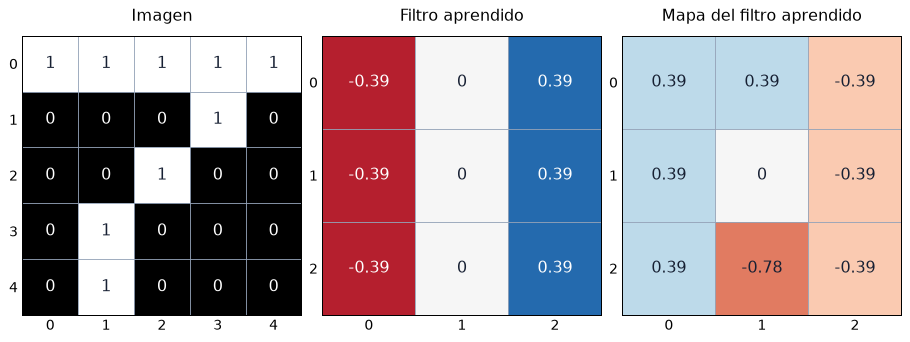

In [15]:
mapa_aprendido = convolucion(imagen, filtro)
fig, ejes = plt.subplots(1, 3, figsize=(10, 3.6), layout="constrained")
dibujar_matriz(ejes[0], imagen, "Imagen")
dibujar_matriz(ejes[1], filtro, "Filtro aprendido", pesos=True, limite=0.5)
dibujar_matriz(ejes[2], mapa_aprendido, "Mapa del filtro aprendido", pesos=True, limite=1.5)
plt.show()

## De este ejemplo a una CNN

**Imagen → filtros aprendidos → mapas de características → combinación de patrones → clase.**

En una CNN, muchas regiones se procesan con los mismos pesos. Varias capas permiten combinar patrones locales en representaciones útiles para la tarea. Durante el entrenamiento, la retropropagación calcula cómo afecta cada parámetro al error final y el optimizador lo actualiza.

Nuestro experimento sí realiza aprendizaje supervisado de un filtro, pero solo distingue dos orientaciones de contraste. Los seis aciertos son sobre los ejemplos usados para entrenar: no prueban generalización. No implementamos una CNN completa, subsampling ni reconocimiento de dígitos.

Referencia: LeCun, Bottou, Bengio y Haffner (1998), [Gradient-Based Learning Applied to Document Recognition](https://proceedingsoftheieee.ieee.org/gradient-based-learning-applied-to-document-recognition/).